Predict house price using multiple factors instead of just one.

Now your model doesn’t just look at one thing, it juggles several clues at once like a detective 🕵️‍♂️

📦 Kaggle Dataset

Use this:

👉 House Prices - Advanced Regression Techniques

Download the train.csv file.

📊 Features we’ll use (keep it simple but powerful)

From the dataset, pick:

GrLivArea → Living area (sq ft)
BedroomAbvGr → Number of bedrooms
FullBath → Number of bathrooms

Target:

SalePrice 💰

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [11]:
# Load the dataset
df = pd.read_csv('train.csv')

print("📊 Dataset Sample:")
print(df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].head())

print(f"\n📋 Total Rows: {df.shape[0]}")
print(f"📋 Total Columns: {df.shape[1]}")
print(f"\n⚠️ Missing Values in Selected Columns:")
print(df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].isnull().sum())

📊 Dataset Sample:
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1710             3         2     208500
1       1262             3         2     181500
2       1786             3         2     223500
3       1717             3         1     140000
4       2198             4         2     250000

📋 Total Rows: 1460
📋 Total Columns: 81

⚠️ Missing Values in Selected Columns:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


In [12]:
# Select features and target
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

X = df[features]
y = df[target]

print("✅ Features and target ready.")
print(f"   Features (X) : {features}")
print(f"   Target   (y) : {target}")
print(f"   X shape      : {X.shape}")
print(f"   y shape      : {y.shape}")

✅ Features and target ready.
   Features (X) : ['GrLivArea', 'BedroomAbvGr', 'FullBath']
   Target   (y) : SalePrice
   X shape      : (1460, 3)
   y shape      : (1460,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split successfully.")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")

✅ Data split successfully.
   Training samples : 1168
   Testing samples  : 292


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Multiple Linear Regression model trained successfully.")
print(f"\n📐 Coefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"   {feature:<20} : {coef:.4f}")
print(f"\n📐 Intercept : {model.intercept_:.4f}")
print(f"\n🧮 Formula:")
print(f"   SalePrice = ({model.coef_[0]:.2f} × GrLivArea)")
print(f"             + ({model.coef_[1]:.2f} × BedroomAbvGr)")
print(f"             + ({model.coef_[2]:.2f} × FullBath)")
print(f"             + {model.intercept_:.2f}")

✅ Multiple Linear Regression model trained successfully.

📐 Coefficients:
   GrLivArea            : 104.0263
   BedroomAbvGr         : -26655.1654
   FullBath             : 30014.3241

📐 Intercept : 52261.7486

🧮 Formula:
   SalePrice = (104.03 × GrLivArea)
             + (-26655.17 × BedroomAbvGr)
             + (30014.32 × FullBath)
             + 52261.75


In [15]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"📊 R² Score : {r2:.4f}")
print(f"📊 MSE      : {mse:.2f}")
print(f"📊 RMSE     : {rmse:.2f}")

📊 R² Score : 0.6341
📊 MSE      : 2806426667.25
📊 RMSE     : 52975.72


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


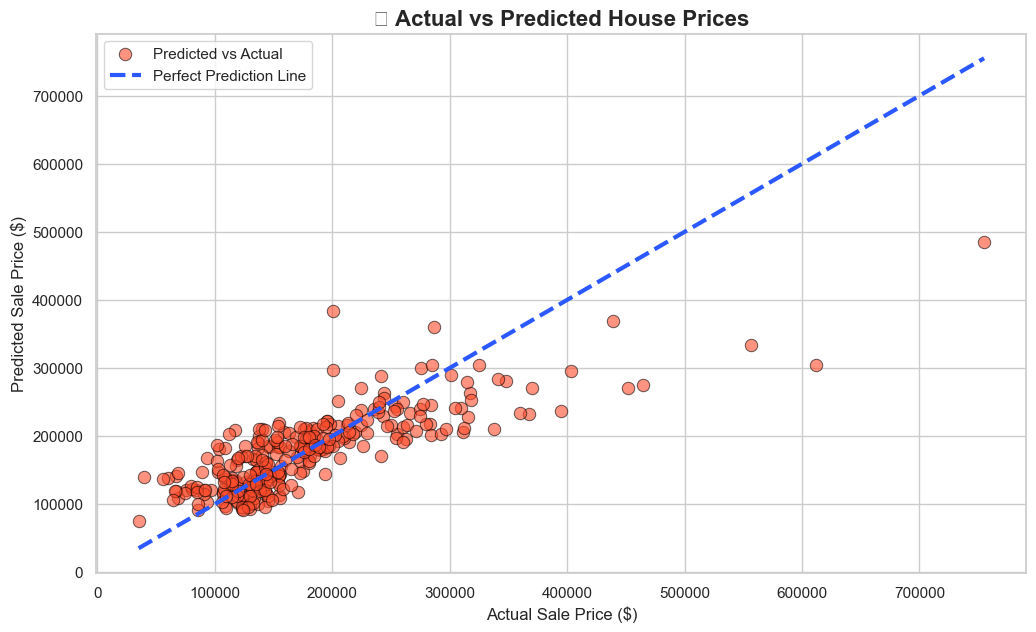

In [16]:
plt.figure(figsize=(12, 7))

sns.scatterplot(x=y_test, y=y_pred,
                color='#ff4b2b', s=80, edgecolor='black', alpha=0.6, label='Predicted vs Actual')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='#2b58ff', linewidth=3, linestyle='--', label='Perfect Prediction Line')

plt.title('🏠 Actual vs Predicted House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3680\1394529798.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df,
C:\Users\User\AppData\Local\Temp\ipykernel_3680\1394529798.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


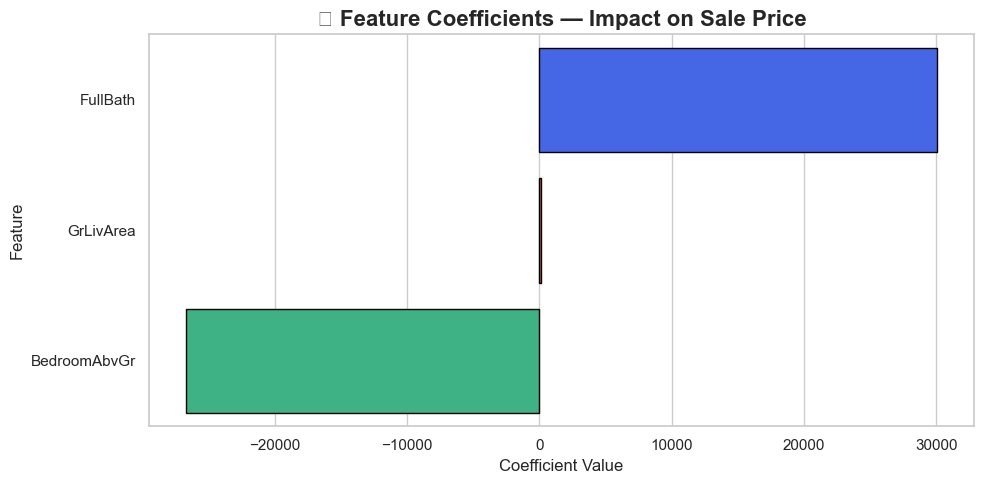

In [17]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df,
            palette=['#2b58ff', '#ff4b2b', '#2bc48a'], edgecolor='black')

plt.title('📊 Feature Coefficients — Impact on Sale Price', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
def predict_house_price(living_area, bedrooms, bathrooms):
    prediction = model.predict([[living_area, bedrooms, bathrooms]])[0]
    print(f"\n🔮 Prediction for:")
    print(f"   Living Area  : {living_area} sq ft")
    print(f"   Bedrooms     : {bedrooms}")
    print(f"   Bathrooms    : {bathrooms}")
    print(f"\n💰 Estimated Sale Price: ${prediction:,.2f}")

try:
    area = float(input("Enter Living Area (sq ft) e.g. 1500: "))
    beds = int(input("Enter Number of Bedrooms e.g. 3: "))
    baths = int(input("Enter Number of Bathrooms e.g. 2: "))
    predict_house_price(area, beds, baths)
except ValueError:
    print("❌ Invalid input! Please enter numeric values.")


🔮 Prediction for:
   Living Area  : 1000.0 sq ft
   Bedrooms     : 3
   Bathrooms    : 2

💰 Estimated Sale Price: $136,351.21


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
